# ***GÖREV 1***

**Part 2 ile başla. Önceki üç harfi bağlam alan veri setini kur (X: 3
harf indeksi, Y: sıradaki harf). Embedding tablosunu (27x2) oluştur,
indeksleme ile embedding'leri**

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open("names.txt", "r").read().splitlines()
words[: 10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set("".join(words))))
stoi = {s : i + 1 for i ,s in enumerate(chars)}
stoi["."] = 0
itos = {i : s for s, i in stoi.items()}

In [5]:
block_size = 3 # [0],[0],[0] ----> [5]  [0],[0],[5] ----> [12]  [0],[5],[12] ----> [12] emma için mesela
X,Y = [],[]

for w in words[:5]:

  print(w)
  context = [0] * block_size

  for ch in w + ".":
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
C = torch.randn((27,2))

In [8]:
C

tensor([[ 1.5846e+00,  2.0628e-01],
        [ 4.7251e-01,  7.0688e-01],
        [-8.8553e-01,  3.6536e-01],
        [-6.9499e-01,  3.7962e-02],
        [ 5.4326e-02, -1.0100e+00],
        [ 1.1005e-01, -2.0060e+00],
        [ 5.6148e-01,  1.3616e+00],
        [-1.9077e+00, -1.1619e+00],
        [ 5.5252e-01, -3.2339e-01],
        [ 1.6559e+00,  3.8540e-01],
        [ 9.9682e-01,  5.4879e-01],
        [-1.7146e-01, -2.9171e-01],
        [ 3.3937e-01, -1.8949e+00],
        [-3.6302e-02,  9.9087e-02],
        [ 2.3839e+00, -2.4128e-01],
        [ 2.1132e+00,  3.0383e-01],
        [ 2.7952e-01,  1.6619e+00],
        [ 2.5078e-01,  1.7976e-02],
        [-1.2948e+00, -9.1873e-01],
        [ 1.0894e+00,  3.0453e-04],
        [ 3.3778e-01, -2.0197e+00],
        [-8.2218e-02,  3.2544e-01],
        [-9.5065e-01,  1.9017e+00],
        [-1.2307e+00, -1.4515e-01],
        [ 2.6023e-01, -9.0643e-01],
        [ 5.1739e-01, -8.5707e-01],
        [ 1.1460e+00, -3.8813e-01]])

In [9]:
C[5]

tensor([ 0.1101, -2.0060])

In [10]:
F.one_hot(torch.tensor(5), num_classes = 27) @ C # dtype hatası verdi

RuntimeError: expected m1 and m2 to have the same dtype, but got: long int != float

In [12]:
F.one_hot(torch.tensor(5), num_classes= 27).float() @ C

tensor([ 0.1101, -2.0060])

In [13]:
print(C[5])

tensor([ 0.1101, -2.0060])


# ***GÖREV 2***

**2. Gizli katmanı ve çıkış katmanını kur: embedding'leri düzleştir, W1
ve b1 ile tanh, W2 ve b2 ile logits. Loss'u geçen haftaki gibi elle
hesapla, sonra F.cross_entropy ile aynı sonucu aldığını göster ve
neden onu tercih ettiğimizi videodan anla. (18:35 - 37:56)**

In [14]:
C

tensor([[ 1.5846e+00,  2.0628e-01],
        [ 4.7251e-01,  7.0688e-01],
        [-8.8553e-01,  3.6536e-01],
        [-6.9499e-01,  3.7962e-02],
        [ 5.4326e-02, -1.0100e+00],
        [ 1.1005e-01, -2.0060e+00],
        [ 5.6148e-01,  1.3616e+00],
        [-1.9077e+00, -1.1619e+00],
        [ 5.5252e-01, -3.2339e-01],
        [ 1.6559e+00,  3.8540e-01],
        [ 9.9682e-01,  5.4879e-01],
        [-1.7146e-01, -2.9171e-01],
        [ 3.3937e-01, -1.8949e+00],
        [-3.6302e-02,  9.9087e-02],
        [ 2.3839e+00, -2.4128e-01],
        [ 2.1132e+00,  3.0383e-01],
        [ 2.7952e-01,  1.6619e+00],
        [ 2.5078e-01,  1.7976e-02],
        [-1.2948e+00, -9.1873e-01],
        [ 1.0894e+00,  3.0453e-04],
        [ 3.3778e-01, -2.0197e+00],
        [-8.2218e-02,  3.2544e-01],
        [-9.5065e-01,  1.9017e+00],
        [-1.2307e+00, -1.4515e-01],
        [ 2.6023e-01, -9.0643e-01],
        [ 5.1739e-01, -8.5707e-01],
        [ 1.1460e+00, -3.8813e-01]])

In [15]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [16]:
C[X]

tensor([[[ 1.5846e+00,  2.0628e-01],
         [ 1.5846e+00,  2.0628e-01],
         [ 1.5846e+00,  2.0628e-01]],

        [[ 1.5846e+00,  2.0628e-01],
         [ 1.5846e+00,  2.0628e-01],
         [ 1.1005e-01, -2.0060e+00]],

        [[ 1.5846e+00,  2.0628e-01],
         [ 1.1005e-01, -2.0060e+00],
         [-3.6302e-02,  9.9087e-02]],

        [[ 1.1005e-01, -2.0060e+00],
         [-3.6302e-02,  9.9087e-02],
         [-3.6302e-02,  9.9087e-02]],

        [[-3.6302e-02,  9.9087e-02],
         [-3.6302e-02,  9.9087e-02],
         [ 4.7251e-01,  7.0688e-01]],

        [[ 1.5846e+00,  2.0628e-01],
         [ 1.5846e+00,  2.0628e-01],
         [ 1.5846e+00,  2.0628e-01]],

        [[ 1.5846e+00,  2.0628e-01],
         [ 1.5846e+00,  2.0628e-01],
         [ 2.1132e+00,  3.0383e-01]],

        [[ 1.5846e+00,  2.0628e-01],
         [ 2.1132e+00,  3.0383e-01],
         [ 3.3937e-01, -1.8949e+00]],

        [[ 2.1132e+00,  3.0383e-01],
         [ 3.3937e-01, -1.8949e+00],
         [ 1.6559e+00,

In [17]:
C[X][:2]

tensor([[[ 1.5846,  0.2063],
         [ 1.5846,  0.2063],
         [ 1.5846,  0.2063]],

        [[ 1.5846,  0.2063],
         [ 1.5846,  0.2063],
         [ 0.1101, -2.0060]]])

In [18]:
C[Y][:2]

tensor([[ 0.1101, -2.0060],
        [-0.0363,  0.0991]])

In [19]:
emb = C[X]
print(emb.shape)

torch.Size([32, 3, 2])


In [20]:
emb_flatten = emb.view(-1,6)
print(emb_flatten.shape)

torch.Size([32, 6])


In [21]:
emb_flatten

tensor([[ 1.5846e+00,  2.0628e-01,  1.5846e+00,  2.0628e-01,  1.5846e+00,
          2.0628e-01],
        [ 1.5846e+00,  2.0628e-01,  1.5846e+00,  2.0628e-01,  1.1005e-01,
         -2.0060e+00],
        [ 1.5846e+00,  2.0628e-01,  1.1005e-01, -2.0060e+00, -3.6302e-02,
          9.9087e-02],
        [ 1.1005e-01, -2.0060e+00, -3.6302e-02,  9.9087e-02, -3.6302e-02,
          9.9087e-02],
        [-3.6302e-02,  9.9087e-02, -3.6302e-02,  9.9087e-02,  4.7251e-01,
          7.0688e-01],
        [ 1.5846e+00,  2.0628e-01,  1.5846e+00,  2.0628e-01,  1.5846e+00,
          2.0628e-01],
        [ 1.5846e+00,  2.0628e-01,  1.5846e+00,  2.0628e-01,  2.1132e+00,
          3.0383e-01],
        [ 1.5846e+00,  2.0628e-01,  2.1132e+00,  3.0383e-01,  3.3937e-01,
         -1.8949e+00],
        [ 2.1132e+00,  3.0383e-01,  3.3937e-01, -1.8949e+00,  1.6559e+00,
          3.8540e-01],
        [ 3.3937e-01, -1.8949e+00,  1.6559e+00,  3.8540e-01, -9.5065e-01,
          1.9017e+00],
        [ 1.6559e+00,  3.8540e

In [22]:
g = torch.Generator().manual_seed(42)
W1 = torch.randn((6,100),generator = g)
b1 = torch.randn(100,generator=g)

h = torch.tanh(emb_flatten @ W1 + b1)
print(h)
print(h.shape)

tensor([[ 9.8912e-01,  9.9954e-01, -8.3440e-01,  ...,  9.8255e-01,
          9.8030e-01,  9.7296e-01],
        [ 9.9958e-01,  1.0000e+00,  9.9194e-01,  ...,  9.9665e-01,
          9.8913e-01,  9.7560e-01],
        [ 9.5948e-01,  9.9005e-01, -9.6653e-01,  ...,  9.9717e-01,
          9.3777e-01, -7.0316e-01],
        ...,
        [ 9.9742e-01,  9.9913e-01,  9.9809e-01,  ...,  9.7880e-01,
         -3.6848e-04,  9.8689e-01],
        [ 3.4776e-01,  5.8915e-01, -8.5725e-01,  ...,  9.7121e-01,
          8.8187e-01,  9.9393e-01],
        [-9.6068e-02,  9.9768e-01, -9.7971e-01,  ...,  9.5818e-01,
          1.5605e-01,  8.9527e-01]])
torch.Size([32, 100])


In [23]:
g = torch.Generator().manual_seed(42)
W2 = torch.randn((100,27),generator = g)
b2 = torch.randn(27,generator=g)

logits = h @ W2 + b2
print(logits.shape)
print(logits[0])

torch.Size([32, 27])
tensor([ 7.6210e+00,  5.4904e+00,  2.7827e+00,  8.7638e+00,  1.1631e+01,
        -1.1747e+01,  1.1719e+00,  4.5734e+00, -7.7833e-01,  6.6193e+00,
        -2.0192e+01, -2.5241e+01,  8.1707e+00, -2.2656e-02, -1.2661e+01,
        -6.0655e+00,  8.7706e+00,  2.7750e+00,  1.2398e+00, -8.9199e+00,
        -1.8227e+01, -6.4842e+00,  1.8167e+00,  1.2015e+01, -4.7817e+00,
        -3.2603e+00,  1.2593e+00])


In [24]:
counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)

In [25]:
probs


tensor([[6.8617e-03, 8.1492e-04, 5.4343e-05, 2.1514e-02, 3.7845e-01, 2.6615e-11,
         1.0855e-05, 3.2574e-04, 1.5439e-06, 2.5198e-03, 5.7188e-15, 3.6693e-17,
         1.1889e-02, 3.2871e-06, 1.0664e-11, 7.8065e-09, 2.1662e-02, 5.3931e-05,
         1.1617e-05, 4.4954e-10, 4.0800e-14, 5.1359e-09, 2.0684e-05, 5.5579e-01,
         2.8182e-08, 1.2904e-07, 1.1846e-05],
        [5.4321e-11, 1.7593e-10, 3.3437e-08, 2.0319e-15, 1.2333e-02, 6.9022e-15,
         3.2209e-12, 1.4536e-03, 9.5234e-11, 1.3304e-03, 9.7503e-12, 1.7585e-13,
         4.0460e-05, 2.1867e-06, 1.0335e-10, 7.4345e-08, 5.0698e-07, 2.9725e-06,
         3.0639e-01, 6.4771e-14, 5.3401e-16, 1.9798e-07, 3.0124e-15, 9.5801e-07,
         6.1041e-12, 3.5564e-13, 6.7844e-01],
        [7.0571e-13, 1.9306e-06, 5.8873e-08, 2.2026e-14, 5.4931e-14, 1.6849e-14,
         3.9969e-05, 6.1556e-14, 2.0704e-11, 1.7304e-06, 1.4049e-06, 1.2725e-13,
         3.8368e-15, 2.8228e-13, 3.9431e-08, 1.9090e-14, 2.8100e-04, 2.2159e-13,
         9.9948e-

In [26]:
print("Her satırın olasılık toplamı:")
print(probs.sum(dim=1))

Her satırın olasılık toplamı:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [27]:
correct_probs = probs[torch.arange(X.shape[0]), Y] # doğru indexe verdiği olasılık

print(correct_probs)

tensor([2.6615e-11, 2.1867e-06, 2.8228e-13, 2.2902e-09, 8.4741e-07, 7.8065e-09,
        7.2588e-03, 9.0272e-03, 1.4243e-12, 2.2923e-05, 7.9446e-04, 3.4354e-03,
        8.1492e-04, 2.0528e-05, 3.1844e-08, 9.4046e-05, 2.5198e-03, 8.3467e-10,
        3.1817e-07, 3.8014e-01, 2.6948e-13, 7.8317e-10, 9.0628e-10, 6.1803e-06,
        1.1857e-17, 4.4954e-10, 9.4261e-11, 3.5605e-03, 2.2274e-05, 1.0616e-07,
        9.8185e-01, 9.7708e-03])


In [28]:
loss_manual = -correct_probs.log().mean() # negative log likelihood yapıyorum

print("Elle hesaplanan loss:", loss_manual.item())

Elle hesaplanan loss: 14.682679176330566


In [29]:
loss_cross_entropy = F.cross_entropy(logits, Y) # Logit veriyorum .Fonksiyon kendi içinde softmax ve negative log likelihood işlemlerini güvenli biçimde yapıyor.
# Daha pratik ve güvenli olduğu için cross entropy tercih etmek daha mantıklı.
print("F.cross_entropy loss:", loss_cross_entropy.item())
print("Aynı mı?:", torch.allclose(loss_manual, loss_cross_entropy))

F.cross_entropy loss: 14.68267822265625
Aynı mı?: True


# ***GÖREV 3***

**3. Eğitim döngüsünü kur: önce tek bir minibatch'i overfit et, sonra
bütün veriyi minibatch'lerle eğit. Learning rate'i videodaki gibi tara
ve iyi bir değer seç. Veriyi train / dev / test olarak böl, loss'u dev
üzerinde raporla.**

In [30]:
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [31]:
lr = 0.1
for step in range(1000):

  emb = C[X]
  h = torch.tanh(emb.view(-1,6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)

  for p in parameters:
    p.grad = None # Her parametrenin üzerinde önceki turdan kalan düzeltme bilgisi olabilir.Yani eski yön bilgiisni sil ve yeni hataya göre hesapla demek


  loss.backward()

  for p in parameters:
    p.data = p.data - lr * p.grad

  if step % 100 == 0:
    print(f"step : {step} loss: {loss.item()}")

step : 0 loss: 14.68267822265625
step : 100 loss: 0.3434354364871979
step : 200 loss: 0.2871682643890381
step : 300 loss: 0.2730208933353424
step : 400 loss: 0.2666122019290924
step : 500 loss: 0.26306676864624023
step : 600 loss: 0.2608671188354492
step : 700 loss: 0.2593804597854614
step : 800 loss: 0.2583093047142029
step : 900 loss: 0.257500022649765


In [32]:
block_size = 3
chars = sorted(list(set("".join(words))))
stoi = {s : i+1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i : s for s , i in stoi.items()}

In [33]:
def build_dataset(words):

  X = []
  Y = []

  for w in words:

    context = block_size * [0]

    for ch in w + ".":

      ix = stoi[ch]
      X.append(context)
      Y.append(ix)

      context = context[1:] + [ix] # Amacını anla

  X = torch.tensor(X)
  Y = torch.tensor(Y)

  print(X.shape, Y.shape)

  return X, Y

In [34]:
import random

random.seed(42)
random.shuffle(words)

# Slice indeksleri tam sayı olmalı
number1 = int(0.8 * len(words))
number2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:number1]) # model paramterleini güncellmelk için kullanılır.
X_dev, Y_dev = build_dataset(words[number1:number2]) # learning rate veya model boyutu gibi kararları güncellemek içiin kullanılır.
X_test, Y_test = build_dataset(words[number2:]) #En son final perfomansını görmek için.

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [35]:
g = torch.Generator().manual_seed(42)

C = torch.randn((27, 2), generator=g, requires_grad=True)

W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)

W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

print(sum(p.nelement() for p in parameters))

3481


In [36]:
ix = torch.randint(0, X_train.shape[0], (32,))

print(ix)
print(X_train[ix].shape)
print(Y_train[ix].shape)

tensor([ 62616, 155044,  63813, 171597,  73526, 149253, 117767,  47582, 135375,
        170446, 127048,  19376, 155302,  85432, 142675, 143635,  73808,   2006,
         54419,  49694, 147384,  50126,   2958,  54481, 100191,   3125,  12542,
        121783,  28147, 166050, 152942,  49157])
torch.Size([32, 3])
torch.Size([32])


In [37]:
lr = 0.1
for step in range(10000):

  ix = torch.randint(0, X_train.shape[0], (32,))

  emb = C[X_train[ix]]
  h = torch.tanh(emb.view(-1,6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)

  for p in parameters:
    p.grad = None


  loss.backward()

  for p in parameters:

    p.data = p.data + (-lr * p.grad)


  if step % 1000 == 0:
    print(f"step : {step} loss: {loss.item()}") #Her adımda farklı 32 örnek seçildiği için minibatch loss’un biraz yukarı ve aşağı oynaması normaldir.

step : 0 loss: 16.004236221313477
step : 1000 loss: 2.326756715774536
step : 2000 loss: 2.294613838195801
step : 3000 loss: 2.304049253463745
step : 4000 loss: 2.3006644248962402
step : 5000 loss: 2.3104443550109863
step : 6000 loss: 2.3052070140838623
step : 7000 loss: 2.3138928413391113
step : 8000 loss: 2.3073880672454834
step : 9000 loss: 2.3168253898620605


In [38]:
@torch.no_grad() # gradyan hesaplama yapma, model eğitmeyeceğim sadece hesaplama yapacağım

def evaluate_loss(X,Y):

  emb = C[X]
  h = torch.tanh(emb.view(-1,6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)

  return loss.item()



print("train loss:", evaluate_loss(X_train, Y_train))
print("dev loss:  ", evaluate_loss(X_dev, Y_dev))

train loss: 6.8556976318359375
dev loss:   6.841235160827637


In [39]:
ix = torch.randint(0, X_train.shape[0], (32,))

print("Yeni minibatch loss:", evaluate_loss(X_train[ix], Y_train[ix]))
print("Tüm train loss:    ", evaluate_loss(X_train, Y_train))
print("Dev loss:          ", evaluate_loss(X_dev, Y_dev))

Yeni minibatch loss: 6.433131694793701
Tüm train loss:     6.8556976318359375
Dev loss:           6.841235160827637


In [40]:
# 1) Modeli bir kez sıfırdan oluştur
g = torch.Generator().manual_seed(11111)

C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)

W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

# 2) Sadece train verisinden minibatch'lerle eğit
for step in range(10000):
    ix = torch.randint(0, X_train.shape[0], (32,))

    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    for p in parameters:
        p.data += -0.1 * p.grad

# 3) Eğitim biter bitmez değerlendir
@torch.no_grad()
def evaluate_loss(X, Y):
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y).item()

print("Son minibatch:", loss.item())
print("_Trainain loss:   ", evaluate_loss(X_train, Y_train))
print("Dev loss:     ", evaluate_loss(X_dev, Y_dev))

Son minibatch: 2.450624704360962
_Trainain loss:    2.486018419265747
Dev loss:      2.483736276626587


In [41]:
# Modeli sıfırdan başlat
g = torch.Generator().manual_seed(42)

C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)

W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

# 0.001 ile 1 arasında, logaritmik aralıklı 1000 learning rate
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

lri = []
lossi = []

for step in range(1000):
    ix = torch.randint(0, X_train.shape[0], (32,))

    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = lrs[step]

    for p in parameters:
        p.data += -lr * p.grad

    lri.append(lre[step].item())
    lossi.append(loss.item())

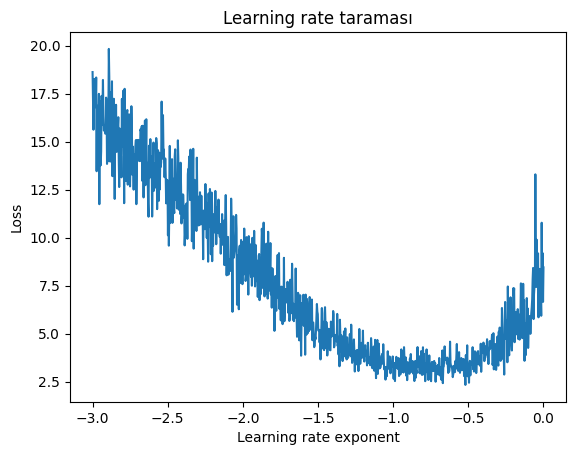

In [42]:
import matplotlib.pyplot as plt

plt.plot(lri, lossi)
plt.xlabel("Learning rate exponent")
plt.ylabel("Loss")
plt.title("Learning rate taraması")
plt.show()

In [43]:
g = torch.Generator().manual_seed(42)

C = torch.randn((27, 2), generator=g, requires_grad=True)
W1 = torch.randn((6, 100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)

W2 = torch.randn((100, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

for step in range(20000):
    ix = torch.randint(0, X_train.shape[0], (32,))

    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    for p in parameters:
        p.data += -0.1 * p.grad

Learning rate taramasından sonra modeli tekrar sıfırdan başlatıyorum. Çünkü tarama sırasında model farklı learning rate’lerle güncellendi; onu final model olarak kullanmak doğru olmaz.

İlk 20 bin adımda 0.1 learning rate kullanıyorum. Son 10 bin adımda learning rate’i 0.01’e düşürüyorum. Bu, model hedefe yaklaşırken daha küçük ve hassas düzeltmeler yapmasını sağlıyor.

In [44]:
print("Train loss:", evaluate_loss(X_train, Y_train))
print("Dev loss:  ", evaluate_loss(X_dev, Y_dev))

Train loss: 2.4393532276153564
Dev loss:   2.438194990158081


# ***Görev 4***

**4. Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl
değiştiğini göster. Embedding'leri 2 boyutta çizdir: hangi harfler
birbirine yakın düşüyor? Modelden isimler örnekle, bigram'ınkilerle
karşılaştır.**

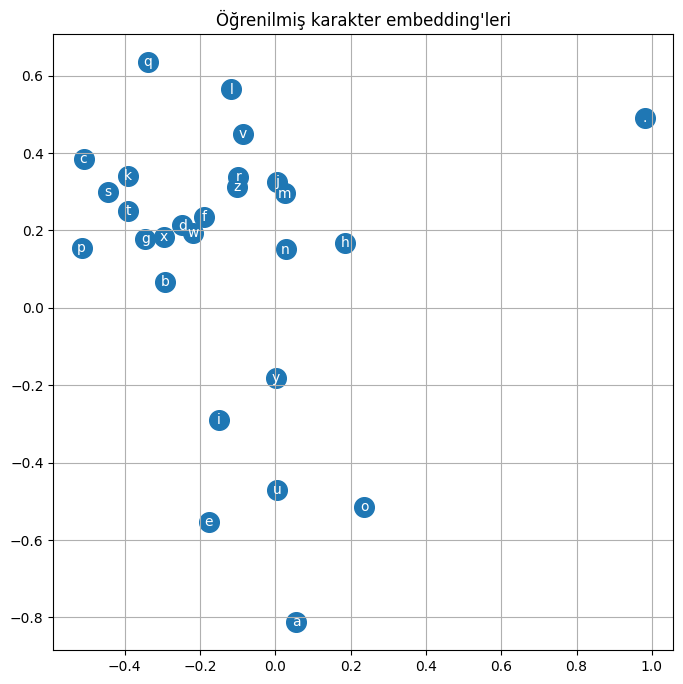

In [45]:
plt.figure(figsize=(8, 8))

plt.scatter(C[:, 0].detach(), C[:, 1].detach(), s=200)

for i in range(C.shape[0]):
    plt.text(
        C[i, 0].item(),
        C[i, 1].item(),
        itos[i],
        ha="center",
        va="center",
        color="white"
    )

plt.grid(True)
plt.title("Öğrenilmiş karakter embedding'leri")
plt.show()

In [47]:
n_embd = 2
n_hidden = 300

g = torch.Generator().manual_seed(42)

C = torch.randn((27, n_embd), generator=g, requires_grad=True)

W1 = torch.randn(
    (block_size * n_embd, n_hidden),
    generator=g,
    requires_grad=True
)
b1 = torch.randn(n_hidden, generator=g, requires_grad=True)

W2 = torch.randn((n_hidden, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

print("Parametre sayısı:", sum(p.nelement() for p in parameters))

for step in range(30000):
    ix = torch.randint(0, X_train.shape[0], (32,))

    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    # İlk bölüm hızlı öğrenme, son bölüm ince ayar
    lr = 0.1 if step < 20000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

Parametre sayısı: 10281


In [48]:
print("Train loss:", evaluate_loss(X_train, Y_train))
print("Dev loss:  ", evaluate_loss(X_dev, Y_dev))

Train loss: 2.3232104778289795
Dev loss:   2.3230056762695312


In [50]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(42)

C = torch.randn((27, n_embd), generator=g, requires_grad=True)

W1 = torch.randn(
    (block_size * n_embd, n_hidden),
    generator=g,
    requires_grad=True
)
b1 = torch.randn(n_hidden, generator=g, requires_grad=True)

W2 = torch.randn((n_hidden, 27), generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]

print("Parametre sayısı:", sum(p.nelement() for p in parameters))

for step in range(100000):
    ix = torch.randint(0, X_train.shape[0], (32,))

    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if step < 50000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

Parametre sayısı: 11897


In [51]:
@torch.no_grad()
def evaluate_loss(X, Y):
    emb = C[X]

    h = torch.tanh(
        emb.view(-1, block_size * n_embd) @ W1 + b1
    )

    logits = h @ W2 + b2

    return F.cross_entropy(logits, Y).item()

In [52]:
print("Train loss:", evaluate_loss(X_train, Y_train))
print("Dev loss:  ", evaluate_loss(X_dev, Y_dev))

Train loss: 2.1805570125579834
Dev loss:   2.2039427757263184


In [53]:
print("Test loss:", evaluate_loss(X_test, Y_test))

Test loss: 2.1964619159698486


In [54]:
g_sample = torch.Generator().manual_seed(42)

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        x = torch.tensor([context])  # Tek örnek oluşturuyoruz

        emb = C[x]
        h = torch.tanh(
            emb.view(-1, block_size * n_embd) @ W1 + b1
        )
        logits = h @ W2 + b2

        # Logitleri olasılığa çevir
        probs = F.softmax(logits, dim=1)

        # Olasılıklara göre sonraki karakteri seç
        ix = torch.multinomial(
            probs,
            num_samples=1,
            generator=g_sample
        ).item()

        context = context[1:] + [ix]

        # Nokta gelirse isim bitti
        if ix == 0:
            break

        out.append(ix)

    print("".join(itos[i] for i in out))

anue
emma
smar
idushante
naysia
yon
aremah
luvan
epiah
nee
jamel
kence
jordon
kalla
mikonya
ashvisia
aceelani
narcepher
mar
tal


# ***GÖREV 5***

**5. Part 3'e geç. Aynı modelde başlangıç loss'unun neden çok yüksek
olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı
çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da
düzeldiğini göster.**

In [62]:
block_size = 3

In [60]:
n_embd = 10
n_hidden = 200
g = torch.Generator().manual_seed(42)


C = torch.randn((27,n_embd),generator=g) # 27 karakter için 10 embedding li


W1 = torch.randn((n_embd * block_size,n_hidden), generator = g)
b1 = torch.randn(n_hidden, generator = g)


W2 = torch.randn((n_hidden,27), generator = g)
b2 = torch.randn(27, generator = g)


ix = torch.randint(0,X_train.shape[0], (32,))

emb = C[X_train[ix]]
h = torch.tanh(emb.view(-1,block_size * n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train[ix])



print("İlk loss:", loss.item())
print("Beklediğimiz loss:", -torch.tensor(1 / 27).log().item())

İlk loss: 28.68385124206543
Beklediğimiz loss: 3.295836925506592


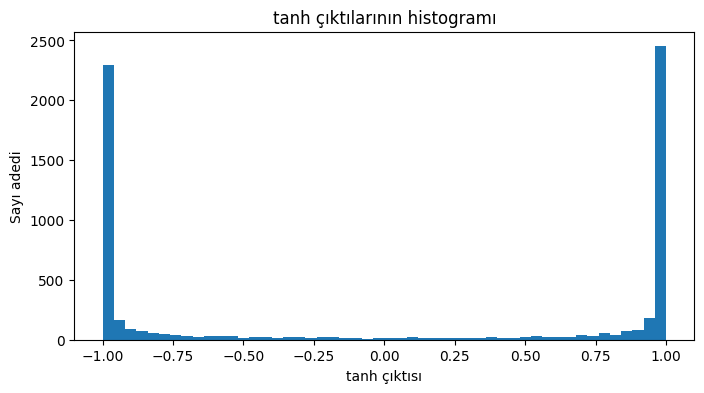

Doymuş aktivasyon oranı:
0.659375011920929


In [61]:
plt.figure(figsize=(8, 4))

plt.hist(h.view(-1).tolist(), bins=50)
plt.title("tanh çıktılarının histogramı")
plt.xlabel("tanh çıktısı")
plt.ylabel("Sayı adedi")
plt.show()

print("Doymuş aktivasyon oranı:")
print((h.abs() > 0.99).float().mean().item())

In [63]:
# Output layer'ı küçük ve sakin başlatıyoruz
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01
b2 = torch.zeros(27)

# Aynı minibatch ile tekrar forward pass
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train[ix])

print("Yeni ilk loss:", loss.item())
print("Beklenen nötr loss:   ", -torch.tensor(1 / 27).log().item())

Yeni ilk loss: 3.3058547973632812
Beklenen nötr loss:    3.295836925506592


In [64]:
g = torch.Generator().manual_seed(42)

# Embedding
C = torch.randn((27, n_embd), generator=g)

# W1: Kaiming init
# 5/3 → tanh için gain
# block_size * n_embd = 30 → W1'in giriş sayısı
W1 = torch.randn(
    (block_size * n_embd, n_hidden),
    generator=g
) * (5 / 3) / ((block_size * n_embd) ** 0.5)

# Bias küçük başlasın
b1 = torch.randn(n_hidden, generator=g) * 0.01

# Output layer küçük başlasın; başlangıçta aşırı emin olmasın
W2 = torch.randn((n_hidden, 27), generator=g) * 0.01
b2 = torch.zeros(27)

# Aynı şekilde tek minibatch ile forward pass
ix = torch.randint(0, X_train.shape[0], (32,))

emb = C[X_train[ix]]
emb_flat = emb.view(-1, block_size * n_embd)

h = torch.tanh(emb.view(-1,block_size * n_embd) @ W1 + b1)

logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train[ix])

print("Kaiming sonrası başlangıç loss:", loss.item())



Kaiming sonrası başlangıç loss: 3.3000478744506836


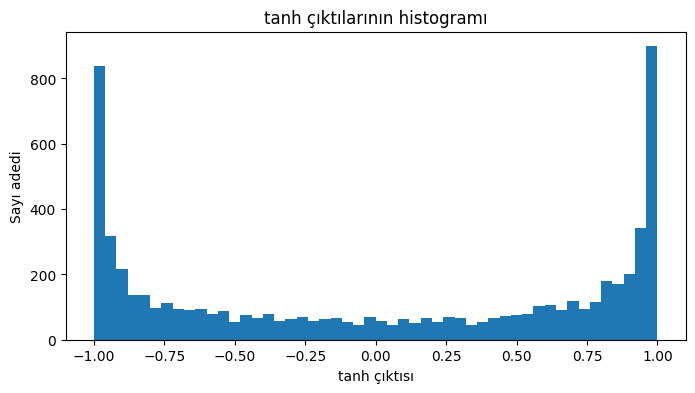

Doymuş aktivasyon oranı:
0.13750000298023224


In [65]:
plt.figure(figsize=(8, 4))

plt.hist(h.view(-1).tolist(), bins=50)
plt.title("tanh çıktılarının histogramı")
plt.xlabel("tanh çıktısı")
plt.ylabel("Sayı adedi")
plt.show()

print("Doymuş aktivasyon oranı:")
print((h.abs() > 0.99).float().mean().item())

# ***Görev 6***

**6. BatchNorm katmanını gizli katmandan sonra ekle. Eğitim sırasında
batch istatistiği, tahmin sırasında running mean kullan. BatchNorm'lu
ve BatchNorm'suz modelin dev loss'unu karşılaştır.**

Kaiming init ile başlangıçtaki depğerleri ayarlamıştık ama ilerleyen kısmılardada aşırı büyüyüp küçülebilir.BatchNorm burada devreye giriyor.

-----------------------------------------------------------

embedding
->
W1
->
hpreact
->
tanh
->
h
---------------------

embedding
->
W1
->
hpreact
->
BatchNorm
->
tanh
->
h

--------------------------------------------------------

Diyelim 32 örnekten oluşan bir minibatch var. Bir hidden nöronun bu 32 örnekteki değerleri şöyle olsun:

[-8, 5, 11, -4, 7, ...]

Bunlar tanh’a doğrudan girerse:

tanh(-8) ≈ -1
tanh(11) ≈ +1

Nöronlar doyar, öğrenmeleri zorlaşır.

BatchNorm bu 32 sayının:

ortalamasını bulur
ne kadar yayıldığını bulur

ve değerleri dengeler.

Sonuç yaklaşık şöyle olur:

[-1.2, 0.4, 1.5, -0.8, 0.7, ...]

Böylece tanh’a daha makul sayılar girer.

O anki 32 örneğin ortalaması ve standart sapması -> batch mean / batch std

---------------------------------------------------------------

running mean------------running std
Bunlar, eğitim boyunca görülen batch’lerin genel ortalama bilgisidir

----------------------------------------------------------------------

bn_gain : bn_gain ile normalleştirilmiş değerleri ölçekleyebiliyor

bn_bias : bn_bias ile sağa sola kaydırabilir

--------------------------------

b1 olmama sebebi b1 eskiden kaydırırdı ama  artık direkt batchnorm tarafından ortalama alındığı için bir anlamı yok

In [66]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(42)

# Model parametreleri
C = torch.randn((27, n_embd), generator=g, requires_grad=True)

W1 = torch.randn(
    (block_size * n_embd, n_hidden),
    generator=g,
    requires_grad=True
) * (5 / 3) / ((block_size * n_embd) ** 0.5)

W2 = torch.randn(
    (n_hidden, 27),
    generator=g,
    requires_grad=True
) * 0.01

b2 = torch.zeros(27, requires_grad=True)

# BatchNorm'un öğrenilebilir parametreleri
bn_gain = torch.ones((1, n_hidden), requires_grad=True)
bn_bias = torch.zeros((1, n_hidden), requires_grad=True)

parameters = [C, W1, W2, b2, bn_gain, bn_bias]

# BatchNorm'un tahmin sırasında kullanacağı değerler
# Bunlar gradient ile öğrenilmez.
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

print("Parametre sayısı:", sum(p.nelement() for p in parameters))

Parametre sayısı: 12097


In [67]:
ix = torch.randint(0, X_train.shape[0], (32,))

emb = C[X_train[ix]]
emb_flat = emb.view(-1, block_size * n_embd)

hpreact = emb_flat @ W1

# O anki 32 örnekten istatistik çıkar
bnmeani = hpreact.mean(dim=0, keepdim=True)
bnstdi = hpreact.std(dim=0, keepdim=True)

# BatchNorm
hpreact_bn = bn_gain * (hpreact - bnmeani) / (bnstdi + 1e-5) + bn_bias

h = torch.tanh(hpreact_bn)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train[ix])

print("İlk loss:", loss.item())
print("BatchNorm sonrası ortalama:", hpreact_bn.mean(dim=0).mean().item())
print("BatchNorm sonrası std:", hpreact_bn.std(dim=0).mean().item())

İlk loss: 3.2824273109436035
BatchNorm sonrası ortalama: -2.2351741291171123e-10
BatchNorm sonrası std: 0.9999935626983643


In [68]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(42)

C = torch.randn((27, n_embd), generator=g, requires_grad=True)

W1 = (
    torch.randn((block_size * n_embd, n_hidden), generator=g)
    * (5 / 3) / ((block_size * n_embd) ** 0.5)
).requires_grad_()

W2 = (
    torch.randn((n_hidden, 27), generator=g) * 0.01
).requires_grad_()

b2 = torch.zeros(27, requires_grad=True)

bn_gain = torch.ones((1, n_hidden), requires_grad=True)
bn_bias = torch.zeros((1, n_hidden), requires_grad=True)

parameters = [C, W1, W2, b2, bn_gain, bn_bias]

# Bunlar parametre değil; gradient ile öğrenilmeyecek.
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

In [69]:
for step in range(100000):
    ix = torch.randint(0, X_train.shape[0], (32,))

    emb = C[X_train[ix]]
    emb_flat = emb.view(-1, block_size * n_embd)

    hpreact = emb_flat @ W1

    # Bu batch'in istatistikleri
    bnmeani = hpreact.mean(dim=0, keepdim=True)
    bnstdi = hpreact.std(dim=0, keepdim=True)

    # Eğitimde batch istatistikleri kullanılır
    hpreact_bn = (
        bn_gain * (hpreact - bnmeani) / (bnstdi + 1e-5)
        + bn_bias
    )

    h = torch.tanh(hpreact_bn)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if step < 50000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    # Running değerleri gradient ile değil, ortalama ile güncelle
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

In [70]:
@torch.no_grad()
def evaluate_loss_bn(X, Y):
    emb = C[X]
    emb_flat = emb.view(-1, block_size * n_embd)

    hpreact = emb_flat @ W1

    # Dev/test aşamasında batch istatistikleri YOK.
    # Eğitim boyunca biriken running değerler kullanılır.
    hpreact_bn = (
        bn_gain * (hpreact - bnmean_running) / (bnstd_running + 1e-5)
        + bn_bias
    )

    h = torch.tanh(hpreact_bn)
    logits = h @ W2 + b2

    return F.cross_entropy(logits, Y).item()

In [71]:
print("BatchNorm'lu train loss:", evaluate_loss_bn(X_train, Y_train))
print("BatchNorm'lu dev loss:  ", evaluate_loss_bn(X_dev, Y_dev))

BatchNorm'lu train loss: 2.094158887863159
BatchNorm'lu dev loss:   2.1235592365264893


BatchNorm'suz dev loss: 2.2096
BatchNorm'lu dev loss:  2.1285

Batchnorm ile daha iyi bir sounç elde ettik